# Building a Neural Network to Approximate the Lotka-Volterra Model

## Plan: NN and PINN for Lotka–Volterra Dynamics

We will compare two approaches for modeling predator–prey dynamics:

1. A **standard neural network (NN)** trained only on observed data  
2. A **physics-informed neural network (PINN)** trained on data *and* the governing equations  

---

## Lotka–Volterra Model

The system is governed by:

$$
\begin{aligned}
\frac{dP}{dt} &= \alpha P - \beta P Z \\
\frac{dZ}{dt} &= \delta P Z - \gamma Z
\end{aligned}
$$

We will:
- Generate synthetic data from this system  
- Train an NN to fit the observations  
- Train a PINN to fit the data and enforce the equations  
- Compare their behavior over time  

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

In [3]:
# -------------------------------------------------
# Lotka–Volterra ODE system
def lotka_volterra_rhs(state, t, alpha, beta, delta, gamma):
    P, Z = state
    dPdt = alpha * P - beta * P * Z
    dZdt = delta * P * Z - gamma * Z
    return np.array([dPdt, dZdt])

def rk4(f, x0, times, tfrc, frc, args):
    """
    Integrate an ODE system using the classical fourth-order Runge-Kutta method.
    Optionally add discrete forcing increments at specified forcing times.
    """
    nt = len(times)
    x = np.zeros((nt, len(x0)))
    x[0, :] = x0

    dt = np.zeros(nt)
    dt[1:] = np.diff(times)

    for n in range(1, nt):
        k1 = f(x[n - 1, :], times[n - 1], *args) * dt[n]
        k2 = f(x[n - 1, :] + 0.5 * k1, times[n - 1] + 0.5 * dt[n], *args) * dt[n]
        k3 = f(x[n - 1, :] + 0.5 * k2, times[n - 1] + 0.5 * dt[n], *args) * dt[n]
        k4 = f(x[n - 1, :] + k3, times[n - 1] + dt[n], *args) * dt[n]

        x[n, :] = x[n - 1, :] + (k1 + 2 * k2 + 2 * k3 + k4) / 6

        if tfrc is not None and frc is not None:
            fl = np.where(
                np.logical_and(
                    tfrc >= times[n] - 0.5 * dt[n],
                    tfrc < times[n] + 0.5 * dt[n]
                )
            )[0]
            x[n, :] += frc[fl, :].sum(axis=0)

    return x

## Generating Synthetic Data and Sparse Observations

We generate a "true" trajectory from the Lotka-Volterra system using RK4 integration.

To mimic real-world data, we do not observe the system continuously. Instead:
- We sample a small number of observation times
- We add noise to the observations
- Some variables may be unobserved at certain times

Missing observations are represented using `NaN`, which we will handle later when defining the loss function.

In [4]:
# Observation setup
error_obs = 0.03
n_obs_P   = 20                        # number of prey observations (0 = unobserved)
n_obs_Z   = 10                        # number of predator observations (0 = unobserved)

# Lotka-Volterra parameters
parameters = {
    'alpha': 1.5,
    'beta':  1.0,
    'delta': 0.75,
    'gamma': 1.0,
}

P0, Z0 = 1.0, 0.5
x0     = np.array([P0, Z0])
T      = 10.0
dt     = 0.01

t_vals = np.arange(0, T, dt)
state  = rk4(lotka_volterra_rhs, x0, t_vals, None, None,
             tuple(parameters.values()))

t_all  = tf.constant(t_vals, dtype=tf.float32)[:, tf.newaxis]
PZ_all = tf.constant(state, dtype=tf.float32)

# -------------------------------------------------
# Build observation array with NaN for unobserved entries
idx_P = sorted(np.random.choice(len(t_vals), size=n_obs_P, replace=False)) if n_obs_P > 0 else []
idx_Z = sorted(np.random.choice(len(t_vals), size=n_obs_Z, replace=False)) if n_obs_Z > 0 else []
idx_all = sorted(set(idx_P) | set(idx_Z))

set_P = set(idx_P)
set_Z = set(idx_Z)
idx_all = sorted(set_P | set_Z)

obs_array = np.full((len(idx_all), 2), np.nan)
t_obs_vals = t_vals[idx_all]

for i, idx in enumerate(idx_all):
    if idx in set_P:
        obs_array[i, 0] = state[idx, 0] + error_obs * np.random.randn()
    if idx in set_Z:
        obs_array[i, 1] = state[idx, 1] + error_obs * np.random.randn()

t_data  = tf.constant(t_obs_vals, dtype=tf.float32)[:, tf.newaxis]
PZ_data = tf.constant(obs_array, dtype=tf.float32)

# Convert to NumPy for plotting and build masks for observed values
PZ_np = PZ_data.numpy()
t_np  = t_data.numpy()

mask_P = ~np.isnan(PZ_np[:, 0])
mask_Z = ~np.isnan(PZ_np[:, 1])

print(f"Total observation times: {len(idx_all)}")
print(f"P observed at {len(idx_P)} times, Z observed at {len(idx_Z)} times")

Total observation times: 30
P observed at 20 times, Z observed at 10 times


### Plot Styling

In [12]:
# ── Colors ─────────────────────────────────────
P_TRUE_COLOR  = "green"
Z_TRUE_COLOR  = "red"
P_MODEL_COLOR = "green"
Z_MODEL_COLOR = "red"
P_OBS_COLOR   = "darkgreen"
Z_OBS_COLOR   = "darkred"

colors = [P_MODEL_COLOR, Z_MODEL_COLOR]

# ── Line styles ────────────────────────────────
LINE_WIDTH    = 2.0
LINE_ALPHA    = 0.15
LINE_STYLE    = "--"

MODEL_LINE_WIDTH = 2.5
MODEL_LINE_ALPHA = 1.0
MODEL_LINE_STYLE = "-"

# ── Scatter ────────────────────────────────────
SCATTER_SIZE   = 70
SCATTER_ZORDER = 3

# ── Text / labels ─────────────────────────────
LABEL_FONTSIZE  = 16
TITLE_FONTSIZE  = 20
TICK_FONTSIZE   = 14
LEGEND_FONTSIZE = 14

TITLE_TEXT  = ""
XLABEL_TEXT = "Time"
YLABEL_TEXT = "Population"

LEGEND_NCOL  = 2
LEGEND_FRAME = False

# ── Legend labels ─────────────────────────────
P_TRUE_LABEL = "P (underlying)"
Z_TRUE_LABEL = "Z (underlying)"
P_OBS_LABEL  = "P observed"
Z_OBS_LABEL  = "Z observed"

### Visualizing the True Dynamics and Observations

We first visualize:
- The full (true) Lotka-Volterra trajectory
- The sparse, noisy observations used for training

This highlights the key challenge:
we only observe the system at a limited number of points in time.

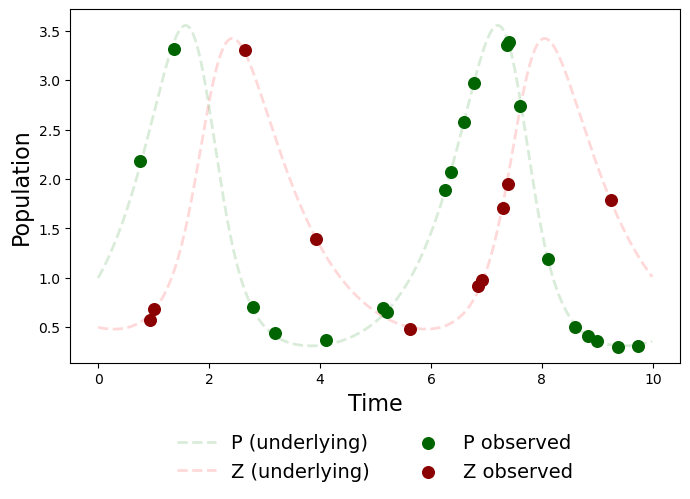

In [7]:
# ── Plot styling (easy to tweak) ─────────────────────────────────────
FIG_SIZE = (7, 5)
plt.figure(figsize=FIG_SIZE)

# True trajectories (context)
plt.plot(t_vals, state[:, 0],
         lw=LINE_WIDTH, alpha=LINE_ALPHA,
         color=P_TRUE_COLOR, label=P_TRUE_LABEL,
        linestyle=LINE_STYLE)

plt.plot(t_vals, state[:, 1],
         lw=LINE_WIDTH, alpha=LINE_ALPHA,
         color=Z_TRUE_COLOR, label=Z_TRUE_LABEL,
        linestyle=LINE_STYLE)

# Observations (focus)
if mask_P.any():
    plt.scatter(t_np[mask_P], PZ_np[mask_P, 0],
                s=SCATTER_SIZE, color=P_OBS_COLOR,
                label=P_OBS_LABEL, zorder=SCATTER_ZORDER)

if mask_Z.any():
    plt.scatter(t_np[mask_Z], PZ_np[mask_Z, 1],
                s=SCATTER_SIZE, color=Z_OBS_COLOR,
                label=Z_OBS_LABEL, zorder=SCATTER_ZORDER)

plt.xlabel(XLABEL_TEXT, fontsize=LABEL_FONTSIZE)
plt.ylabel(YLABEL_TEXT, fontsize=LABEL_FONTSIZE)
plt.title(TITLE_TEXT, fontsize=TITLE_FONTSIZE)

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=False,
    fontsize=LEGEND_FONTSIZE
)

plt.tight_layout(rect=[0, 0.1, 1, 1])

plt.tight_layout()
plt.show()

## Building a Neural Network

We use a feedforward neural network to map time `t` to the populations `[P(t), Z(t)]`.

Instead of using `model.fit()`, we train the model with an explicit `tf.GradientTape` loop.

This is not strictly necessary for a standard neural network, but it becomes important for physics-informed neural networks (PINNs), where we need derivatives of the network output with respect to time.

Using the same training structure for both models makes it easier to introduce the physics-based loss later.

In [ ]:
# Neural networks learn by adjusting weights from their starting values.
# Poor initialization can cause gradients to vanish or explode,
# making training slow or unstable. Xavier/Glorot initialization
# scales weights based on layer size to keep gradients well-behaved.
# -------------------------------------------------
# Neural network architecture
# Input: time t
# Output: [P(t), Z(t)]

init_nn = tf.keras.initializers.GlorotUniform()

num_hidden_neurons = 64
num_output_neurons = 2

model_nn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(num_hidden_neurons, activation='gelu', kernel_initializer=init_nn),
    tf.keras.layers.Dense(num_hidden_neurons, activation='gelu', kernel_initializer=init_nn),
    tf.keras.layers.Dense(num_hidden_neurons, activation='gelu', kernel_initializer=init_nn),
    tf.keras.layers.Dense(num_output_neurons)
])
# Adam = adaptive gradient descent (works well out of the box)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

### Training Setup

In [9]:
# -------------------------------------------------
# Training setup
n_epochs = 2500
plot_epochs = [0, 100, 500, 1000, 2500]

t_test = t_all
PZ_test_true = PZ_all

# Mask missing entries so the loss only uses observed values
mask = tf.cast(~tf.math.is_nan(PZ_data), tf.float32)
PZ_safe = tf.where(tf.math.is_nan(PZ_data), 0.0, PZ_data)

# NumPy copies for plotting
PZ_np = PZ_data.numpy()
t_np = t_data.numpy()

### Training Setup

We define the number of training epochs and the epochs at which we will visualize the model prediction.

We also prepare a mask so that the loss is only computed where observations are available.


Starting training...


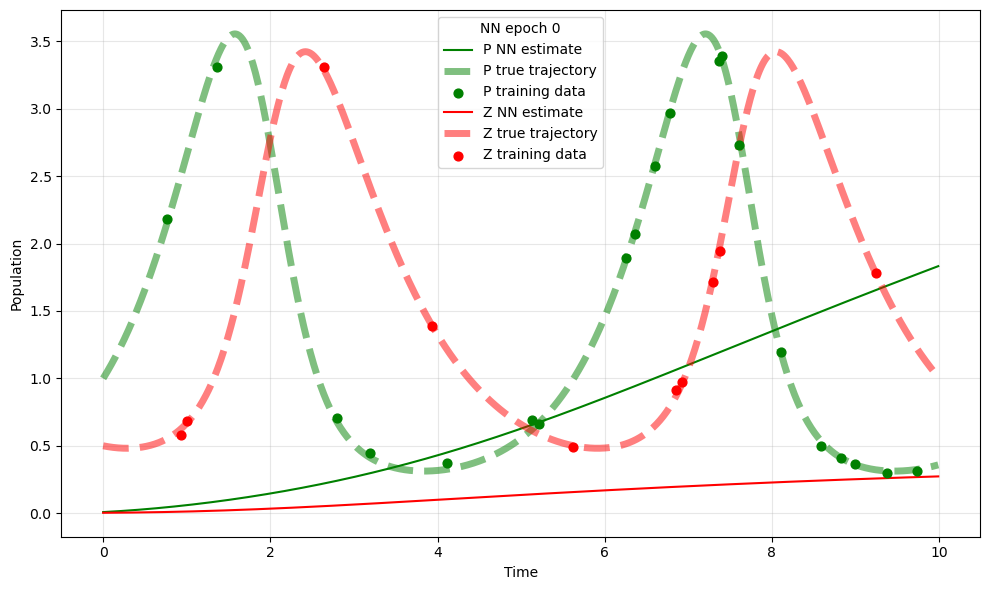

  Full domain MSE at epoch 0: 2.726041
  Phytoplankton MSE: 2.301173, Zooplankton MSE: 3.150908


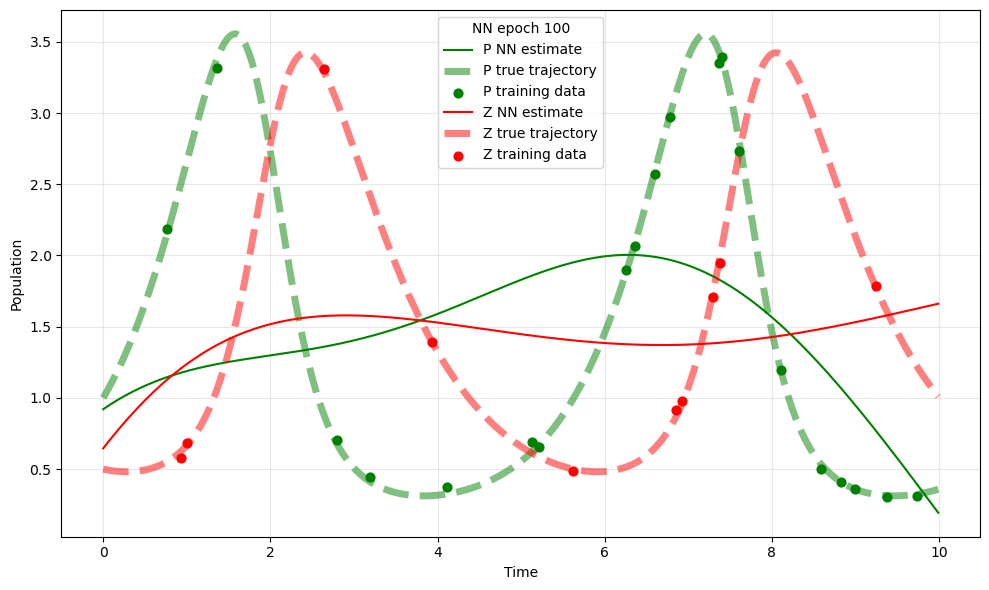

  Full domain MSE at epoch 100: 1.033893
  Phytoplankton MSE: 1.165494, Zooplankton MSE: 0.902292


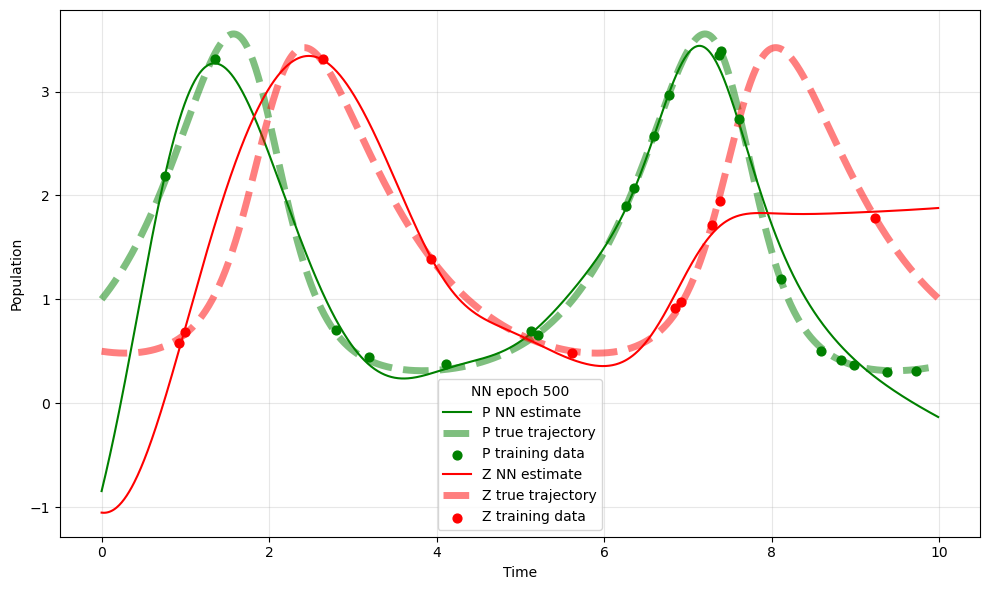

  Full domain MSE at epoch 500: 0.255693
  Phytoplankton MSE: 0.113964, Zooplankton MSE: 0.397422


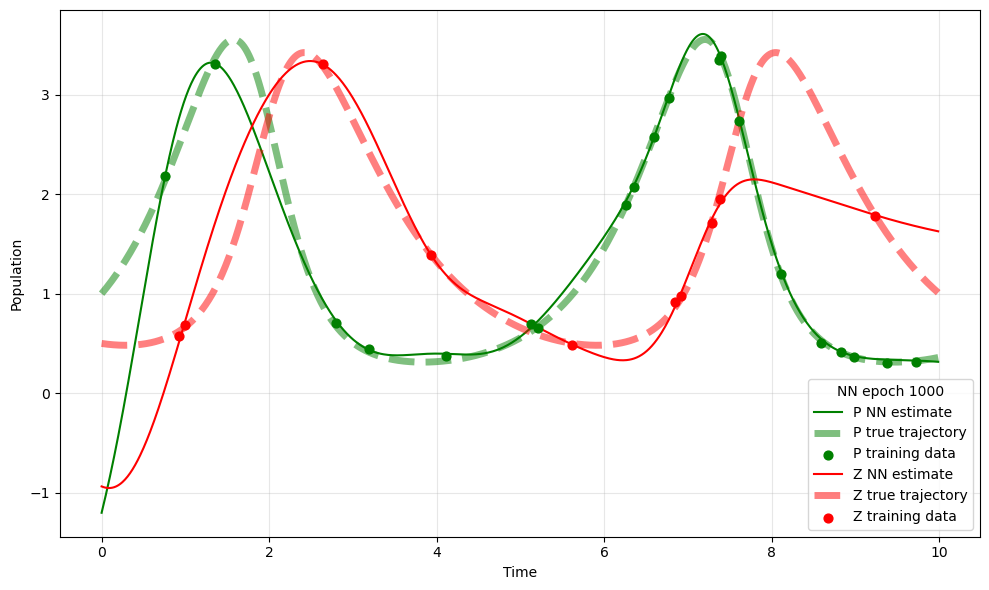

  Full domain MSE at epoch 1000: 0.224534
  Phytoplankton MSE: 0.148628, Zooplankton MSE: 0.300440


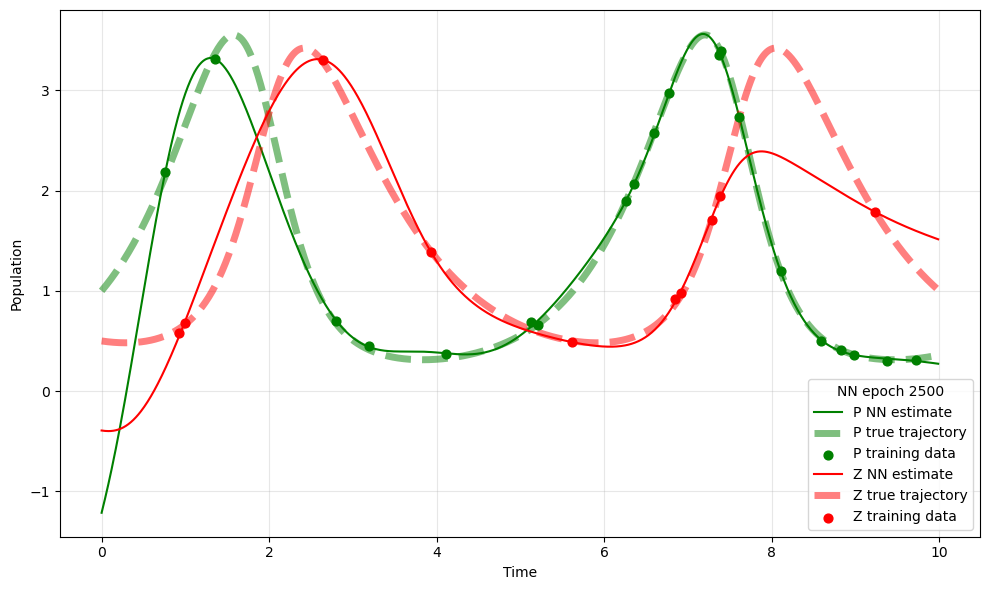

  Full domain MSE at epoch 2500: 0.157803
  Phytoplankton MSE: 0.152904, Zooplankton MSE: 0.162701


In [14]:
print("\nStarting training...")
for epoch in range(n_epochs + 1):
    with tf.GradientTape() as tape:
        pred = model_nn(t_data)
        loss = tf.reduce_sum(mask * (pred - PZ_safe)**2) / tf.reduce_sum(mask)

    grads = tape.gradient(loss, model_nn.trainable_variables)
    optimizer.apply_gradients(zip(grads, model_nn.trainable_variables))

    if epoch in plot_epochs:
        PZ_pred_epoch = model_nn(t_test)

        fig, ax = plt.subplots(figsize=(10, 6))
        for i, var in enumerate(['P', 'Z']):
            color = colors[i]
            ax.plot(t_test.numpy(), PZ_pred_epoch.numpy()[:, i], color=color,
                    label=f'{var} NN estimate')
            ax.plot(t_test.numpy(), PZ_test_true.numpy()[:, i], color=color,
                    ls='--', alpha=0.5, lw=5, label=f'{var} true trajectory')
            m = ~np.isnan(PZ_np[:, i])
            if m.any():
                ax.scatter(t_np[m], PZ_np[m, i], color=color,
                           s=40, zorder=5, label=f'{var} training data')

        ax.legend(title=f'NN epoch {epoch}')
        ax.set(xlabel='Time', ylabel='Population')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        full_error = tf.reduce_mean((PZ_pred_epoch - PZ_test_true)**2).numpy()
        prey_error = tf.reduce_mean((PZ_pred_epoch[:, 0] - PZ_test_true[:, 0])**2).numpy()
        pred_error = tf.reduce_mean((PZ_pred_epoch[:, 1] - PZ_test_true[:, 1])**2).numpy()

        print(f"  Full domain MSE at epoch {epoch}: {full_error:.6f}")
        print(f"  Phytoplankton MSE: {prey_error:.6f}, Zooplankton MSE: {pred_error:.6f}")

In [15]:
# Final NN prediction on full domain
PZ_pred_final = model_nn(t_all)

# -------------------------------------------------
# Compute MSE/RMSE for each population
mse_prey = np.mean((PZ_all.numpy()[:, 0] - PZ_pred_final.numpy()[:, 0])**2)
mse_predator = np.mean((PZ_all.numpy()[:, 1] - PZ_pred_final.numpy()[:, 1])**2)
print(f"NN MSE on full domain -- Prey: {mse_prey:.6f}, Predator: {mse_predator:.6f}")

rmse_prey = np.sqrt(mse_prey)
rmse_predator = np.sqrt(mse_predator)
print(f"NN RMSE on full domain -- Prey: {rmse_prey:.6f}, Predator: {rmse_predator:.6f}")

NN MSE on full domain -- Prey: 0.173525, Predator: 0.097072
NN RMSE on full domain -- Prey: 0.416564, Predator: 0.311564


# Building a PINN

## From a Standard Neural Network to a PINN

**Standard Neural Network**
- Input: time `t`
- Output: `[P(t), Z(t)]`
- Loss: fits the (sparse) observations only

**Physics-Informed Neural Network (PINN)**
- Input: time `t`
- Output: `[P(t), Z(t)]`
- Loss:
  1. **Data loss** → fit the observations
  2. **Physics loss** → enforce the Lotka–Volterra equations

## Main Idea

We use TensorFlow automatic differentiation to compute  
`dP/dt` and `dZ/dt` directly from the neural network output.

These derivatives are then compared to the governing equations,  
and the network is penalized if they do not match.

In [ ]:
# PINN architecture
init_pinn = tf.keras.initializers.GlorotUniform()

model_pinn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(64, activation='gelu', kernel_initializer=init_pinn),
    tf.keras.layers.Dense(64, activation='gelu', kernel_initializer=init_pinn),
    tf.keras.layers.Dense(64, activation='gelu', kernel_initializer=init_pinn),
    tf.keras.layers.Dense(2, kernel_initializer=init_pinn)
])

### Trainable Quantities and Collocation Points

In the PINN, we learn both:
- The neural network weights
- The parameters of the Lotka-Volterra equations

In addition to fitting observed data, we also enforce the governing equations at a set of **collocation points** in time.

These are points where we do not have observations, but where we require the model to satisfy the ODE.

In [17]:
# Trainable ODE parameters
pinn_alpha = tf.Variable(1.0, dtype=tf.float32)
pinn_beta  = tf.Variable(1.0, dtype=tf.float32)
pinn_delta = tf.Variable(1.0, dtype=tf.float32)
pinn_gamma = tf.Variable(1.0, dtype=tf.float32)

ode_params = [pinn_alpha, pinn_beta, pinn_delta, pinn_gamma]

# Combine NN weights and ODE parameters
train_vars = model_pinn.trainable_variables + ode_params

# Optimizer
pinn_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3, epsilon=1e-8)

# Collocation points (where we enforce the ODE)
n_collocation = 200
t_phys = tf.constant(
    np.linspace(0, T, n_collocation),
    dtype=tf.float32
)[:, tf.newaxis]

# Weight on physics loss
lam = 1.0

### Training Setup

We define the number of training epochs and the epochs at which we will visualize the model predictions.

As before, we handle missing observations using a mask, so that the data loss is only computed where observations are available.

In [19]:
# Training settings
n_epochs = 2500
plot_epochs = [0, 100, 500, 1000, 2500]

t_test = t_all
PZ_test_true = PZ_all

# Replace NaNs with zero so they don't affect loss,
# and use mask to only compute loss where data exists
mask = tf.cast(~tf.math.is_nan(PZ_data), tf.float32)
PZ_safe = tf.where(tf.math.is_nan(PZ_data), 0.0, PZ_data)

# NumPy copies for plotting
PZ_np = PZ_data.numpy()
t_np = t_data.numpy()

### PINN Loss: Fit the Data and Enforce the Governing Equations

The PINN loss has two components:

1. **Data loss** → fit the observed values  
2. **Physics loss** → enforce the Lotka–Volterra equations  

The physics loss measures how well the neural network satisfies the differential equations.

To compute the physics loss, we need the time derivatives of the network output.

We use TensorFlow automatic differentiation (`GradientTape`) to compute  
$\frac{dP}{dt}$ and $\frac{dZ}{dt}$ directly from the neural network.

These derivatives are evaluated at **collocation points**, which do not need to coincide with the observation times.

In [20]:
# -------------------------------------------------
# PINN loss function
def pinn_loss(model, t_obs, mask, PZ_safe, t_phys, lam,
              learned_alpha, learned_beta, learned_delta, learned_gamma):
    """
    Compute total PINN loss for the Lotka-Volterra system.

    Total loss = data loss + lam * physics loss
    """

    # 1. Data loss: fit observed values where data exist
    PZ_pred_obs = model(t_obs)
    loss_data = tf.reduce_sum(mask * (PZ_pred_obs - PZ_safe)**2) / tf.reduce_sum(mask)

    # 2. Physics loss: enforce the ODE at collocation points
    # Compute derivatives of network output with respect to time
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(t_phys)

        PZ_phys = model(t_phys)
        P_phys = PZ_phys[:, 0:1]
        Z_phys = PZ_phys[:, 1:2]

    dPdt = tape.gradient(P_phys, t_phys)
    dZdt = tape.gradient(Z_phys, t_phys)
    del tape

    # 3. Residuals of the Lotka-Volterra equations
    f_P = dPdt - (learned_alpha * P_phys - learned_beta * P_phys * Z_phys)
    f_Z = dZdt - (learned_delta * P_phys * Z_phys - learned_gamma * Z_phys)

    loss_phys = tf.reduce_mean(f_P**2 + f_Z**2)

    # 4. Total loss
    total_loss = loss_data + lam * loss_phys

    return total_loss, loss_data, loss_phys



### Train the PINN

We train the PINN by minimizing the combined loss (data + physics) using gradient-based optimization.

At each epoch:
- We compute the total loss using `pinn_loss`
- We compute gradients with respect to both the neural network weights and the ODE parameters
- We update all trainable variables using the optimizer

We periodically visualize the model prediction and monitor:
- Total loss
- Data loss
- Physics loss
- Learned ODE parameters


Starting PINN training...
Epoch 0: Total = 3.823768 | Data = 3.604313 | Physics = 0.219454 | Elapsed = 0.11 s


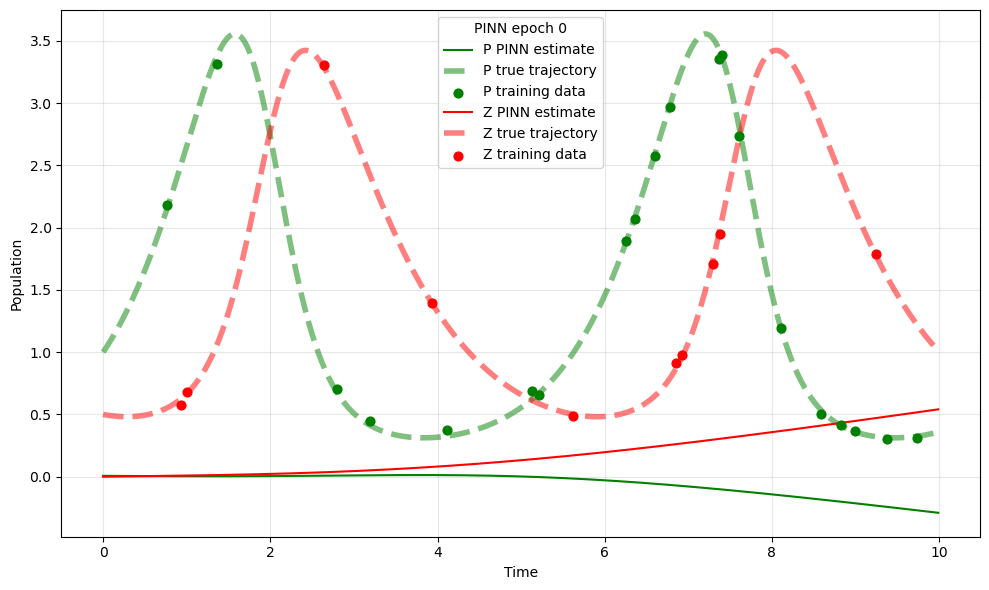

  Full domain MSE: 3.194147
  P MSE: 3.397543
  Z MSE: 2.990752
  Learned parameters: alpha = 0.9990, beta = 1.0010, delta = 0.9990, gamma = 0.9990

Epoch 100: Total = 1.204327 | Data = 1.140565 | Physics = 0.063762 | Elapsed = 3.14 s


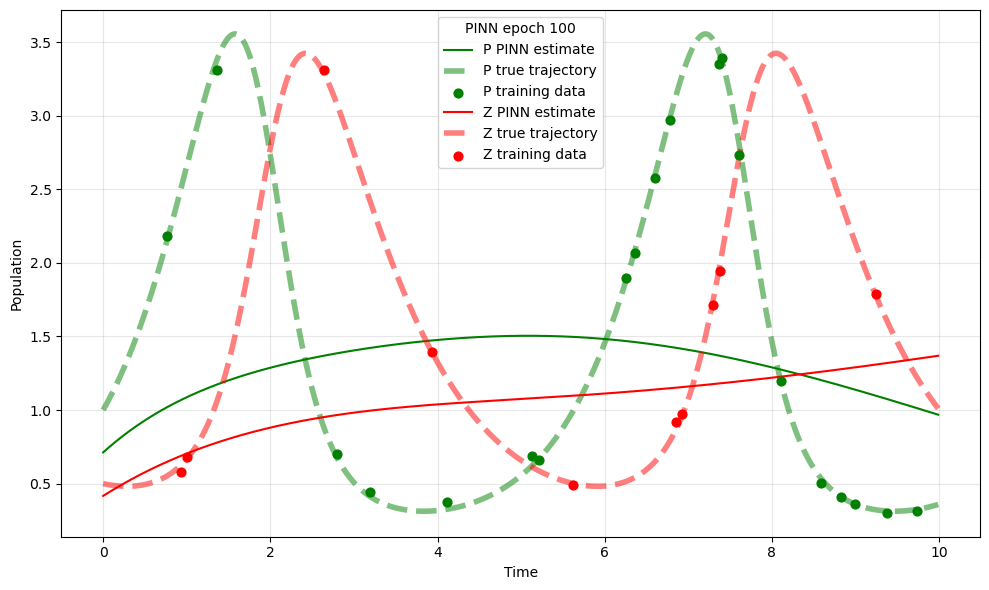

  Full domain MSE: 1.285229
  P MSE: 1.312713
  Z MSE: 1.257746
  Learned parameters: alpha = 1.0146, beta = 0.9681, delta = 0.9229, gamma = 1.0600

Epoch 500: Total = 0.075507 | Data = 0.047872 | Physics = 0.027635 | Elapsed = 15.49 s


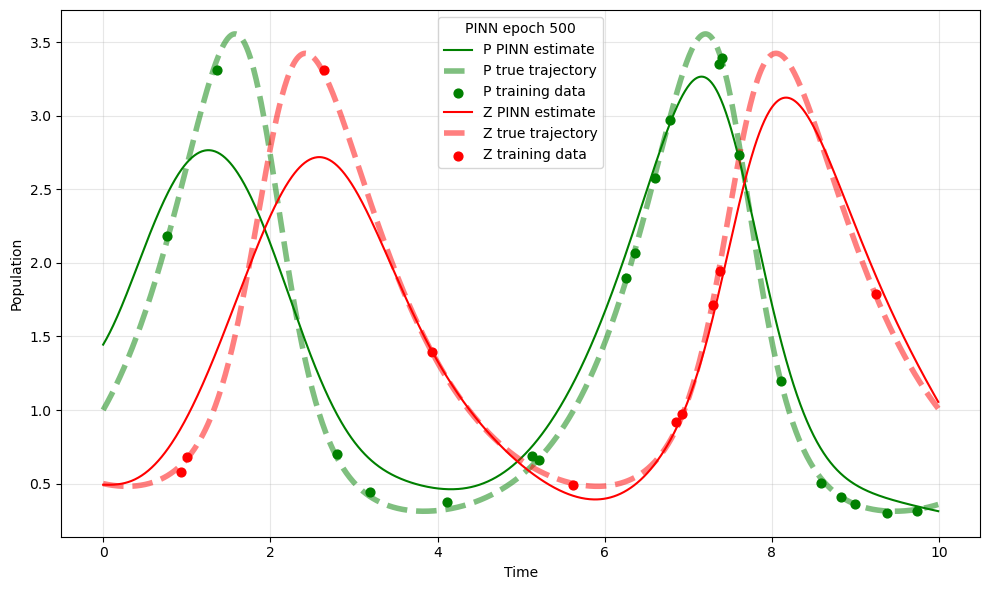

  Full domain MSE: 0.076494
  P MSE: 0.094947
  Z MSE: 0.058041
  Learned parameters: alpha = 1.1232, beta = 0.8302, delta = 0.7570, gamma = 1.0126

Epoch 1000: Total = 0.013568 | Data = 0.004561 | Physics = 0.009008 | Elapsed = 31.00 s


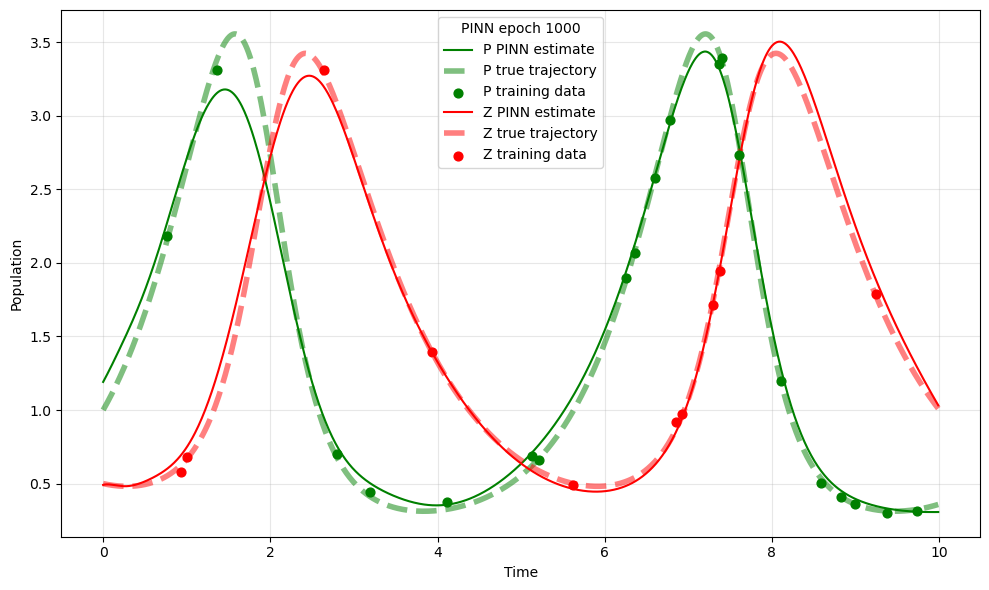

  Full domain MSE: 0.011956
  P MSE: 0.017749
  Z MSE: 0.006164
  Learned parameters: alpha = 1.2905, beta = 0.8737, delta = 0.7797, gamma = 1.0339

Epoch 2500: Total = 0.001660 | Data = 0.000782 | Physics = 0.000878 | Elapsed = 77.49 s


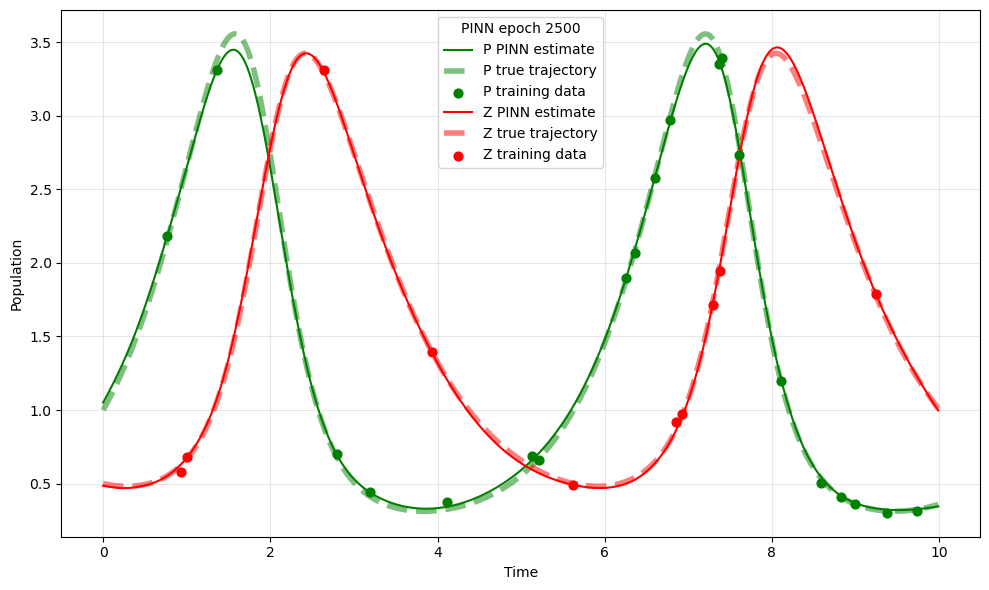

  Full domain MSE: 0.000956
  P MSE: 0.001599
  Z MSE: 0.000312
  Learned parameters: alpha = 1.4182, beta = 0.9514, delta = 0.7770, gamma = 1.0338

PINN training finished in 77.59 seconds (1.29 minutes)


In [21]:
# Train the PINN
print("\nStarting PINN training...")
start_time = time.time()

for epoch in range(n_epochs + 1):

    # Outer GradientTape:
    # compute gradients of the total loss with respect to
    # the network weights and ODE parameters
    # Compute gradients of total loss w.r.t. NN weights and ODE parameters
    with tf.GradientTape() as tape:
        loss_total, loss_data_val, loss_phys_val = pinn_loss(
            model_pinn, t_data, mask, PZ_safe, t_phys, lam,
            pinn_alpha, pinn_beta, pinn_delta, pinn_gamma
        )

    grads = tape.gradient(loss_total, train_vars)
    pinn_optimizer.apply_gradients(zip(grads, train_vars))

    if epoch in plot_epochs:
        elapsed = time.time() - start_time
        PZ_pred_epoch = model_pinn(t_test)

        print(f"Epoch {epoch}: "
              f"Total = {loss_total.numpy():.6f} | "
              f"Data = {loss_data_val.numpy():.6f} | "
              f"Physics = {loss_phys_val.numpy():.6f} | "
              f"Elapsed = {elapsed:.2f} s")

        fig, ax = plt.subplots(figsize=(10, 6))
        for i, (var, color) in enumerate(zip(['P', 'Z'], colors)):
            ax.plot(t_test.numpy(), PZ_pred_epoch.numpy()[:, i], color=color,
                    label=f'{var} PINN estimate')
            ax.plot(t_test.numpy(), PZ_test_true.numpy()[:, i], color=color,
                    ls='--', alpha=0.5, lw=4, label=f'{var} true trajectory')

            m = ~np.isnan(PZ_np[:, i])
            if m.any():
                ax.scatter(t_np[m], PZ_np[m, i], color=color,
                           s=40, zorder=5, label=f'{var} training data')

        ax.legend(title=f'PINN epoch {epoch}')
        ax.set_xlabel('Time')
        ax.set_ylabel('Population')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        full_error = tf.reduce_mean((PZ_pred_epoch - PZ_test_true)**2).numpy()
        prey_error = tf.reduce_mean((PZ_pred_epoch[:, 0] - PZ_test_true[:, 0])**2).numpy()
        pred_error = tf.reduce_mean((PZ_pred_epoch[:, 1] - PZ_test_true[:, 1])**2).numpy()

        print(f"  Full domain MSE: {full_error:.6f}")
        print(f"  P MSE: {prey_error:.6f}")
        print(f"  Z MSE: {pred_error:.6f}")
        print(f"  Learned parameters:"
              f" alpha = {pinn_alpha.numpy():.4f},"
              f" beta = {pinn_beta.numpy():.4f},"
              f" delta = {pinn_delta.numpy():.4f},"
              f" gamma = {pinn_gamma.numpy():.4f}\n")

total_elapsed = time.time() - start_time
print(f"PINN training finished in {total_elapsed:.2f} seconds "
      f"({total_elapsed/60:.2f} minutes)")

### Final PINN Model Evaluation

In [22]:
# Final evaluation on the full domain
PZ_pinn_pred = model_pinn(t_all)

# Compute MSE/RMSE for each population
mse_prey = np.mean((PZ_all.numpy()[:, 0] - PZ_pinn_pred.numpy()[:, 0])**2)
mse_predator = np.mean((PZ_all.numpy()[:, 1] - PZ_pinn_pred.numpy()[:, 1])**2)

print(f"PINN MSE -- Prey: {mse_prey:.6f}, Predator: {mse_predator:.6f}")

rmse_prey = np.sqrt(mse_prey)
rmse_predator = np.sqrt(mse_predator)

print(f"PINN RMSE -- Prey: {rmse_prey:.6f}, Predator: {rmse_predator:.6f}\n")

# Compare learned ODE parameters to the true values
print(f"True alpha: {parameters['alpha']:.4f}, Learned alpha: {pinn_alpha.numpy():.4f}")
print(f"True beta:  {parameters['beta']:.4f}, Learned beta:  {pinn_beta.numpy():.4f}")
print(f"True delta: {parameters['delta']:.4f}, Learned delta: {pinn_delta.numpy():.4f}")
print(f"True gamma: {parameters['gamma']:.4f}, Learned gamma: {pinn_gamma.numpy():.4f}")

PINN MSE -- Prey: 0.001599, Predator: 0.000312
PINN RMSE -- Prey: 0.039993, Predator: 0.017661

True alpha: 1.5000, Learned alpha: 1.4182
True beta:  1.0000, Learned beta:  0.9514
True delta: 0.7500, Learned delta: 0.7770
True gamma: 1.0000, Learned gamma: 1.0338


## PINNs: Pros and Cons

### Pros
- Incorporate physical knowledge directly into training
- Perform well with sparse or incomplete data
- Can learn unknown physical parameters
- Produce more physically consistent solutions than standard neural networks

### Cons
- Training can be unstable (balancing data vs. physics loss)
- Sensitive to hyperparameters (e.g., $\lambda$, collocation points)
- Struggle with extrapolation
- Can be computationally expensive

### Extrapolation Beyond the Training Domain

We now evaluate the PINN beyond the time interval used during training.

This highlights an important limitation:
even though PINNs incorporate physical structure, they can still struggle to generalize outside the training domain.

We compare the PINN prediction to the true trajectory beyond the training window.

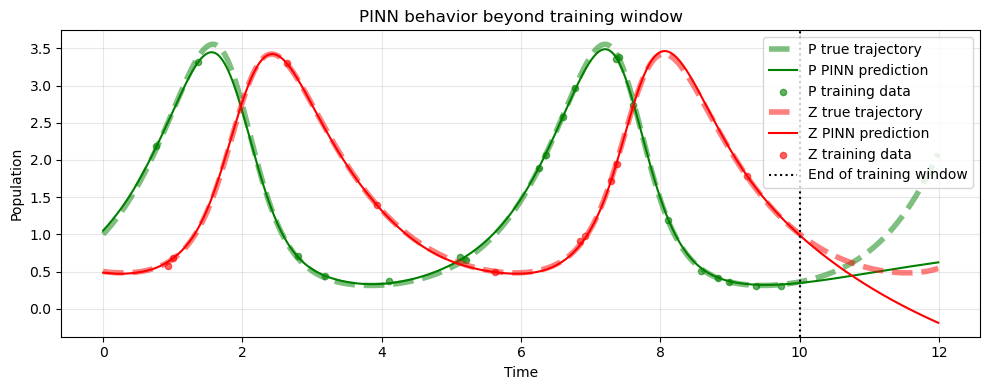

In [23]:
# Evaluate PINN slightly beyond the training window

# Extend time beyond the training interval [0, T]
T_extra = 2.0
t_extended_vals = np.arange(0, T + T_extra, dt)

t_extended = tf.constant(t_extended_vals, dtype=tf.float32)[:, tf.newaxis]

# True trajectory (for comparison)
PZ_true_extended = rk4(
    lotka_volterra_rhs,
    x0,
    t_extended_vals,
    None,
    None,
    tuple(parameters.values())
)

# PINN prediction
PZ_pinn_extended = model_pinn(t_extended)

# -------------------------------------------------
# Plot extrapolation
fig, ax = plt.subplots(figsize=(10, 4))

for i, var in enumerate(['P', 'Z']):
    color = colors[i]
    # True trajectory
    ax.plot(t_extended_vals, PZ_true_extended[:, i],
            color=color, ls='--', alpha=0.5, lw=4,
            label=f'{var} true trajectory')

    # PINN prediction
    ax.plot(t_extended_vals, PZ_pinn_extended.numpy()[:, i],
            color=color, label=f'{var} PINN prediction')

    # Training data (only within [0, T])
    m = ~np.isnan(PZ_np[:, i])
    if m.any():
        ax.scatter(t_np[m], PZ_np[m, i],
                   color=color, s=20, alpha=0.6,
                   label=f'{var} training data')

# Vertical line showing end of training window
# This shows where the model leaves the training domain
ax.axvline(T, color='k', linestyle=':', label='End of training window')

ax.set_xlabel("Time")
ax.set_ylabel("Population")
ax.set_title("PINN behavior beyond training window")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()